In [1]:
import os
os.makedirs('images', exist_ok=True)
print("Working directory:", os.getcwd())

Working directory: /content


In [2]:
!pip install tensorflow keras numpy pandas scikit-learn tqdm

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
DRIVE_ZIP_PATH = '/content/archive.zip'

In [6]:
import zipfile
import os
import shutil

# --- Copy the file from Drive to the current environment ---
local_zip_file = 'fashion-product-images-small.zip'
print(f"Copying {DRIVE_ZIP_PATH} to {local_zip_file}...")
shutil.copyfile(DRIVE_ZIP_PATH, local_zip_file)
print("Copy complete.")

# --- Extraction ---
extract_path = '.'

# Create 'images' directory if it doesn't exist
if not os.path.exists('images'):
    os.makedirs('images')

try:
    with zipfile.ZipFile(local_zip_file, 'r') as zip_ref:
        print("Extracting dataset... This may take a few minutes.")
        # Only extract the 'images' folder if the zip contains it
        zip_ref.extractall(extract_path)

    # Verify the extraction
    if 'images' in os.listdir('.'):
        print("Successfully found 'images' directory. You can now proceed to Feature Extraction (Step 2.B).")
    else:
        print("Extraction finished, but the 'images' directory was not found in the expected location. Please check the contents of your zip file.")

except FileNotFoundError:
    print(f" Error: The file {DRIVE_ZIP_PATH} was not found on your Google Drive. Double-check the path in Step 2.")
except Exception as e:
    print(f" An error occurred during extraction: {e}")

Copying /content/archive.zip to fashion-product-images-small.zip...
Copy complete.
Extracting dataset... This may take a few minutes.
Successfully found 'images' directory. You can now proceed to Feature Extraction (Step 2.B).


In [7]:
import os
for root, dirs, files in os.walk('.'):
    imgs = [f for f in files if f.endswith(('.jpg', '.jpeg', '.png'))]
    if imgs:
        print(f"Found {len(imgs)} images in: {root}")
        break

Found 44441 images in: ./myntradataset/images


In [8]:
import tensorflow
from tensorflow.keras.preprocessing import image
from tensorflow.keras.layers import GlobalMaxPooling2D
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
import numpy as np
from numpy.linalg import norm
import os
from tqdm import tqdm
import pickle
from sklearn.neighbors import NearestNeighbors

# Load Pre-trained Model (ResNet50)
# ResNet50 is used for feature extraction.
model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
model.trainable = False
model = tensorflow.keras.Sequential([model, GlobalMaxPooling2D()])
print("Model loaded successfully.")

# Define Feature Extraction Function
def extract_features(img_path, model):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    expanded_img_array = np.expand_dims(img_array, axis=0)
    preprocessed_img = preprocess_input(expanded_img_array)
    result = model.predict(preprocessed_img, verbose=0).flatten()
    normalized_result = result / norm(result)
    return normalized_result

# Extract Features and Save

# Setting it to 5000 will be much faster than 60,000+
MAX_IMAGES_TO_PROCESS = 14000
# ------------------------------

filenames = []
# Ensure 'images' directory exists before listing
if not os.path.isdir('images'):
    print("Error: 'images' directory not found. Please re-run the data extraction steps.")
else:
    for file in os.listdir('images'):
        if file.endswith(('.jpg', '.jpeg', '.png')):
            filenames.append(os.path.join('images', file))

print(f"Total images found: {len(filenames)}. Will process up to {min(len(filenames), MAX_IMAGES_TO_PROCESS)} images.")

# Trim the list to the maximum number allowed
filenames_subset = filenames[:MAX_IMAGES_TO_PROCESS]

feature_list = []
# Process only the subset
for file in tqdm(filenames_subset, desc="Extracting Features"):
    try:
        # Pass the model and file to the function
        feature_list.append(extract_features(file, model))
    except Exception as e:
        # print(f"Skipping {file} due to error: {e}")
        continue

# Save the extracted features and filenames from the subset
pickle.dump(feature_list, open('embeddings_subset.pkl', 'wb'))
pickle.dump(filenames_subset, open('filenames_subset.pkl', 'wb'))
print(f"\nFeature extraction complete for subset. Saved {len(feature_list)} embeddings.")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Model loaded successfully.
Total images found: 44441. Will process up to 14000 images.


Extracting Features: 100%|██████████| 14000/14000 [23:16<00:00, 10.03it/s]



Feature extraction complete for subset. Saved 14000 embeddings.


Loaded 14000 features for recommendation.
KNN model trained successfully.

--- UPLOAD YOUR QUERY IMAGE ---


Saving 1613.jpg to 1613.jpg

Processing uploaded image: 1613.jpg
Recommendations found based on visual similarity.


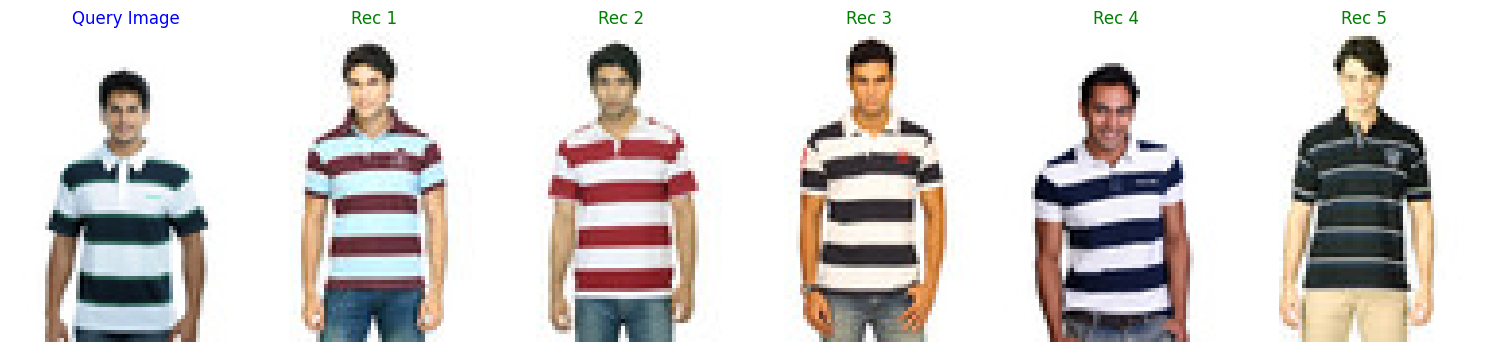

In [15]:
import pickle
from sklearn.neighbors import NearestNeighbors
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files # Tool for handling Colab file uploads
import os # Ensure os is imported

# --- 1. Load Data ---
# Ensure the filenames match the subset files you created earlier
try:
    feature_list = np.array(pickle.load(open('embeddings_subset.pkl', 'rb')))
    filenames = pickle.load(open('filenames_subset.pkl', 'rb'))
    print(f"Loaded {len(feature_list)} features for recommendation.")
except FileNotFoundError:
    print("Error: 'embeddings_subset.pkl' or 'filenames_subset.pkl' not found.")
    raise

# --- 2. Train KNN Model (If not already in memory) ---
neighbors = NearestNeighbors(n_neighbors=6, algorithm='brute', metric='euclidean')
neighbors.fit(feature_list)
print("KNN model trained successfully.")


# --- 3. Define Recommendation & Display Functions (Unchanged) ---

def recommend(features, n_recommendations=5):
    """Finds the indices of the closest neighbors to the query features."""
    distances, indices = neighbors.kneighbors([features])
    recommended_indices = indices[0][1:n_recommendations + 1]
    return [filenames[i] for i in recommended_indices]

def display_recommendations(image_path, recommendations):
    """Displays the query image and its recommendations."""
    plt.figure(figsize=(15, 6))

    # Query Image
    plt.subplot(1, 6, 1)
    img_query = Image.open(image_path)
    plt.imshow(img_query)
    plt.title("Query Image", color='blue')
    plt.axis('off')

    # Recommended Images
    for i, rec_path in enumerate(recommendations):
        plt.subplot(1, 6, i + 2)
        img_rec = Image.open(rec_path)
        plt.imshow(img_rec)
        plt.title(f"Rec {i+1}", color='green')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# --- 4. User Input and Test the Recommender ---

# Create a temporary directory for uploaded images
UPLOAD_DIR = 'uploaded_images'
if not os.path.exists(UPLOAD_DIR):
    os.makedirs(UPLOAD_DIR)

print("\n--- UPLOAD YOUR QUERY IMAGE ---")
# This command will open a file browser for you to select and upload an image
uploaded = files.upload()

if uploaded:
    # Get the name of the first uploaded file
    query_filename = list(uploaded.keys())[0]

    # Move the uploaded file to a temporary folder
    query_image_path = os.path.join(UPLOAD_DIR, query_filename)
    os.rename(query_filename, query_image_path)

    print(f"\nProcessing uploaded image: {query_filename}")

    try:
        # Extract features for the uploaded image
        # Requires the 'model' object and 'extract_features' function from previous cells
        query_features = extract_features(query_image_path, model)

        # Get recommendations
        recommendations = recommend(query_features, n_recommendations=5)

        # Display results
        print(f"Recommendations found based on visual similarity.")
        display_recommendations(query_image_path, recommendations)

    except Exception as e:
        print(f"\n❌ Could not run the recommendation test. Error: {e}")
        print("Ensure the uploaded file is a valid image (jpg/png) and the 'model' object is loaded.")

else:
    print("\nNo file uploaded. Re-run the cell to try again.")

In [ ]:
import tensorflow
from tensorflow.keras.preprocessing import image
from tensorflow.keras.layers import GlobalMaxPooling2D
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
import numpy as np
from numpy.linalg import norm
import os
from tqdm import tqdm
import pickle
from sklearn.neighbors import NearestNeighbors # Not strictly needed for *creation* but common context

# --- 1. Load Pre-trained Model (ResNet50) ---
# ResNet50 is used for feature extraction.
model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
model.trainable = False
model = tensorflow.keras.Sequential([model, GlobalMaxPooling2D()])
print("Model loaded successfully.")
#

# --- 2. Define Feature Extraction Function ---
def extract_features(img_path, model):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    expanded_img_array = np.expand_dims(img_array, axis=0)
    preprocessed_img = preprocess_input(expanded_img_array)
    # The 'model' predicts the feature vector (embedding)
    result = model.predict(preprocessed_img, verbose=0).flatten()
    # Normalize the vector for better distance calculation (KNN)
    normalized_result = result / norm(result)
    return normalized_result

# --- 3. Extract Features and Save ---

# --- Define the limit (since you requested a subset previously) ---
MAX_IMAGES_TO_PROCESS = 5000
# ------------------------------

filenames = []
# Ensure 'images' directory exists before listing
if not os.path.isdir('images'):
    print("Error: 'images' directory not found. Please ensure your dataset is correctly extracted.")
    # Stop execution if data is missing
    raise FileNotFoundError("images directory not found.")
else:
    for file in os.listdir('images'):
        if file.endswith(('.jpg', '.jpeg', '.png')):
            filenames.append(os.path.join('images', file))

print(f"Total images found: {len(filenames)}. Will process up to {min(len(filenames), MAX_IMAGES_TO_PROCESS)} images.")

# Trim the list to the maximum number allowed
filenames_subset = filenames[:MAX_IMAGES_TO_PROCESS]

feature_list = []
# Process only the subset
for file in tqdm(filenames_subset, desc="Extracting Features"):
    try:
        feature_list.append(extract_features(file, model))
    except Exception as e:
        # Simple error handling for corrupted files
        continue

# --- SAVE THE FILES ---
# 1. Store the feature vectors (embeddings)
pickle.dump(feature_list, open('embeddings_subset.pkl', 'wb'))
# 2. Store the corresponding image paths
pickle.dump(filenames_subset, open('filenames_subset.pkl', 'wb'))

print(f"\nFeature extraction complete for subset.")
print(f"✅ Created 'embeddings_subset.pkl' with {len(feature_list)} features.")
print(f"✅ Created 'filenames_subset.pkl' with {len(filenames_subset)} file paths.")